# Preparing the |+⟩ State on a 0-1-r Rydberg System

In the digital-analog mapping protocol the qubit is encoded in two
hyperfine clock states

$$\;|0\rangle = |5S_{1/2}, F{=}1, m_F{=}0\rangle,\qquad |1\rangle = |5S_{1/2}, F{=}2, m_F{=}0\rangle,$$

and the analog dynamics live in the Rydberg manifold $|r\rangle = |nS_{1/2}, m_J{=}{-}1/2\rangle$.
The full Hamiltonian is

$$
H(t)/\hbar =
\frac{\Omega_R(t)}{2}\sum_i\left(|r_i\rangle\langle 1_i| + \mathrm{h.c.}\right)
-\Delta_R(t)\sum_i n_i^r
+\frac{\Omega_{\rm hf}(t)}{2}\sum_i\left(|1_i\rangle\langle 0_i| + \mathrm{h.c.}\right)
-\Delta_{\rm hf}(t)\sum_i n_i^1
+\sum_{i<j} V_{ij}\, n_i^r n_j^r .
$$

This is exactly the `"01r"` level structure in `ryd_gate`, driven by
`DigitalAnalogProtocol`, whose four channels map one-to-one onto the
Hamiltonian terms:

| Channel    | Term                                          | `Segment` field |
|------------|-----------------------------------------------|-----------------|
| `drive_R`  | $\frac{\Omega_R}{2}(|r\rangle\langle 1| + h.c.)$ | `omega_R`       |
| `drive_hf` | $\frac{\Omega_{\rm hf}}{2}(|1\rangle\langle 0| + h.c.)$ | `omega_hf`      |
| `delta_R`  | $-\Delta_R\, n^r$                              | `delta_R`       |
| `delta_hf` | $-\Delta_{\rm hf}\, n^1$                       | `delta_hf`      |

**Goal.** Prepare the active superposition $|+\rangle = (|1\rangle + |r\rangle)/\sqrt{2}$
on each site, by two routes:

1. **Map-up route:** prepare $(|0\rangle + |1\rangle)/\sqrt2$ in the hyperfine
   qubit, then map it up to $(|1\rangle + |r\rangle)/\sqrt2$.
2. **Direct route:** from $|1\rangle$, drive a single $\pi/2$ Rydberg pulse.

We verify both give $\langle n_1\rangle = \langle n_r\rangle = \tfrac12$, then show
why naively putting half the population in $|r\rangle$ **fails on an
interacting lattice** because of the Rydberg blockade.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ryd_gate import RydbergSystem, simulate
from ryd_gate.lattice import make_chain
from ryd_gate.protocols.digital_analog import DigitalAnalogProtocol, Segment
from ryd_gate.core.rydberg_system import InteractionSpec

## Conventions and helpers

With the convention $H = \frac{\Omega}{2}(|a\rangle\langle b| + h.c.)$ the population
transferred from $|b\rangle$ to $|a\rangle$ is $\sin^2(\Omega t/2)$, so a

- **$\pi$ pulse** (full transfer) has duration $t_\pi = \pi/\Omega$,
- **$\pi/2$ pulse** (equal superposition) has duration $t_{\pi/2} = \pi/(2\Omega)$.

We work in natural units with $\Omega_R = \Omega_{\rm hf} = 2\pi$, so one
Rabi period is one time unit. The helper below builds a single-atom
`"01r"` system for a given protocol and returns the population of every
level along the trajectory (prepending the $t=0$ point).

In [2]:
OMEGA_R = 2 * np.pi
OMEGA_HF = 2 * np.pi

t_pi_R = np.pi / OMEGA_R
t_pi2_R = np.pi / (2 * OMEGA_R)
t_pi_hf = np.pi / OMEGA_HF
t_pi2_hf = np.pi / (2 * OMEGA_HF)


def run_single_atom(protocol, initial_level):
    """Build a 1-atom 01r system (no interaction) and evolve from |initial_level>."""
    system = RydbergSystem.from_lattice(
        make_chain(1), level_structure="01r",
        interaction=InteractionSpec(C6=0.0), protocol=protocol,
    )
    psi0 = system.product_state([initial_level])
    result = simulate(system, [], psi0, t_eval=True)  # store every step
    return system, psi0, result


def level_trajectories(system, psi0, result):
    """Return (times, {level: populations}) including the t=0 point."""
    times = np.concatenate([[0.0], result.times])
    states = [psi0, *result.states]
    pops = {
        lvl: np.array([system.expectation(f"n_{lvl}_0", psi) for psi in states])
        for lvl in system.basis.local_levels
    }
    return times, pops

## A single $\pi/2$ Rydberg pulse from $|1\rangle$

The simplest preparation. Start in $|1\rangle$ and drive the
$|1\rangle\leftrightarrow|r\rangle$ transition for a quarter Rabi cycle.

In [9]:
proto_direct = DigitalAnalogProtocol(
    [Segment(duration=t_pi2_R, omega_R=OMEGA_R)],
    n_steps=200,
)
system = RydbergSystem.from_lattice(
        make_chain(1), level_structure="01r",
        interaction=InteractionSpec(C6=0.0), protocol=proto_direct,
    )
psi0 = system.product_state("1")
result = simulate(system, [], psi0, t_eval=True)
times = np.concatenate([[0.0], result.times])
states = [psi0, *result.states]
pops = {
    lvl: np.array([system.expectation(f"n_{lvl}_0", psi) for psi in states])
    for lvl in system.basis.local_levels
}
psi_final = states[-1]
psi_plus = (system.product_state("1") + system.product_state("r")) / np.sqrt(2)
fidelity = np.abs(np.vdot(psi_plus, psi_final)) ** 2
print(f"Fidelity to (|1> + |r>)/sqrt(2): {fidelity:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
colors = {"0": "tab:gray", "1": "tab:blue", "r": "tab:red"}
# Route 2
for lvl in ("0", "1", "r"):
    ax.plot(times, pops[lvl], color=colors[lvl], lw=2, label=fr"$\langle n_{lvl}\rangle$")
ax.axhline(0.5, color="k", ls=":", lw=1)
ax.set_title(r"Route 2: single $\pi/2$ Rydberg pulse")
ax.set_xlabel("time (Rabi periods)")
ax.set_ylabel("population")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'overlap'

## Route 1 (map-up): $\pi/2$ hyperfine $\to$ $\pi$ Rydberg $\to$ $\pi$ hyperfine

Starting from $|0\rangle$:

1. **$\pi/2$ on $|0\rangle\!\leftrightarrow\!|1\rangle$** → $(|0\rangle + |1\rangle)/\sqrt2$.
2. **$\pi$ on $|1\rangle\!\leftrightarrow\!|r\rangle$** maps the $|1\rangle$ component up → $(|0\rangle + |r\rangle)/\sqrt2$.
3. **$\pi$ on $|0\rangle\!\leftrightarrow\!|1\rangle$** relabels the idle component → $(|1\rangle + |r\rangle)/\sqrt2$.

The hyperfine drive does not touch $|r\rangle$, so step 3 leaves the
Rydberg amplitude alone.

In [4]:
proto_mapup = DigitalAnalogProtocol(
    [
        Segment(duration=t_pi2_hf, omega_hf=OMEGA_HF),  # 1. pi/2 on 0-1
        Segment(duration=t_pi_R, omega_R=OMEGA_R),       # 2. pi on 1-r
        Segment(duration=t_pi_hf, omega_hf=OMEGA_HF),    # 3. pi on 0-1
    ],
    n_steps=600,
)
sys_m, psi0_m, res_m = run_single_atom(proto_mapup, initial_level="0")
t_m, pops_m = level_trajectories(sys_m, psi0_m, res_m)

# Segment boundaries (for plotting)
seg_bounds = np.cumsum([t_pi2_hf, t_pi_R, t_pi_hf])

print("Route 1 — final populations:")
for lvl in ("0", "1", "r"):
    print(f"  <n_{lvl}> = {pops_m[lvl][-1]:.4f}")

Route 1 — final populations:
  <n_0> = 0.0000
  <n_1> = 0.5000
  <n_r> = 0.5000


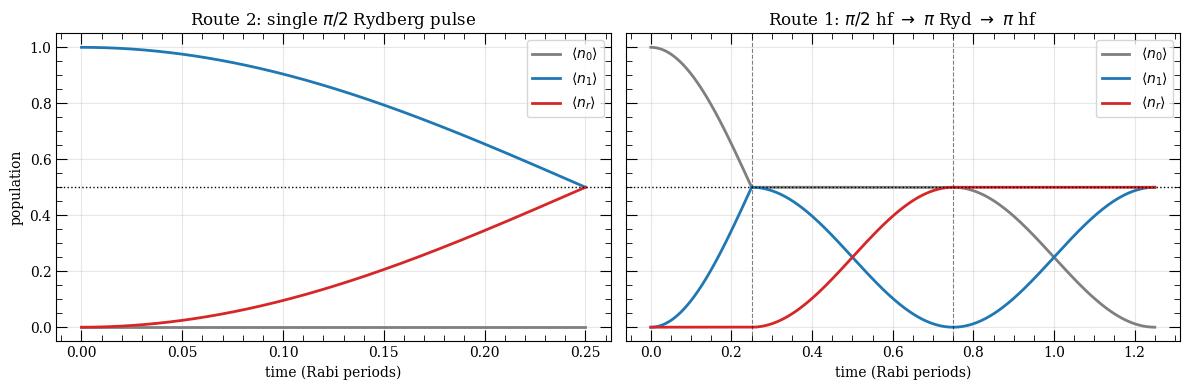

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
colors = {"0": "tab:gray", "1": "tab:blue", "r": "tab:red"}

# Route 2
for lvl in ("0", "1", "r"):
    axes[0].plot(t_d, pops_d[lvl], color=colors[lvl], lw=2, label=fr"$\langle n_{lvl}\rangle$")
axes[0].axhline(0.5, color="k", ls=":", lw=1)
axes[0].set_title(r"Route 2: single $\pi/2$ Rydberg pulse")
axes[0].set_xlabel("time (Rabi periods)")
axes[0].set_ylabel("population")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Route 1
for lvl in ("0", "1", "r"):
    axes[1].plot(t_m, pops_m[lvl], color=colors[lvl], lw=2, label=fr"$\langle n_{lvl}\rangle$")
for b in seg_bounds[:-1]:
    axes[1].axvline(b, color="k", ls="--", lw=0.8, alpha=0.5)
axes[1].axhline(0.5, color="k", ls=":", lw=1)
axes[1].set_title(r"Route 1: $\pi/2$ hf $\to$ $\pi$ Ryd $\to$ $\pi$ hf")
axes[1].set_xlabel("time (Rabi periods)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Both routes land at $\langle n_1\rangle = \langle n_r\rangle = 1/2$ with the qubit
fully out of $|0\rangle$ — the target $|+\rangle = (|1\rangle + |r\rangle)/\sqrt2$.
Route 1 visibly shuttles the population $|0\rangle\to|1\rangle\to|r\rangle$ through
the three segments; route 2 reaches the same endpoint in a single pulse.

## Why naive $|+\rangle$ prep breaks on an interacting lattice

Preparing $|+\rangle$ on every site means the target many-body state is
$\big[(|1\rangle+|r\rangle)/\sqrt2\big]^{\otimes n}$, which contains the
doubly-excited component $|r_i r_j\rangle$. On a real lattice the van der
Waals shift $V_{ij}$ is non-negligible during the mapping pulse, and the
Rydberg blockade suppresses $|r_i r_j\rangle$ — so the per-site Rydberg
occupation falls below $1/2$ and the product state is corrupted.

We demonstrate on two neighbouring atoms (route 2 applied to both),
comparing the non-interacting case to a strong-blockade case
($V_{\rm nn} = 10\,\Omega_R$).

In [ ]:
SPACING_UM = 4.0

def run_two_atoms(C6):
    proto = DigitalAnalogProtocol(
        [Segment(duration=t_pi2_R, omega_R=OMEGA_R)], n_steps=200,
    )
    system = RydbergSystem.from_lattice(
        make_chain(2, spacing_um=SPACING_UM), level_structure="01r",
        interaction=InteractionSpec(C6=C6), protocol=proto,
    )
    psi0 = system.product_state(["1", "1"])
    result = simulate(system, [], psi0, t_eval=True)
    return system, psi0, result

V_nn_target = 10 * OMEGA_R
C6_blockade = V_nn_target * SPACING_UM ** 6

sys_free, psi0_free, res_free = run_two_atoms(C6=0.0)
sys_blk, psi0_blk, res_blk = run_two_atoms(C6=C6_blockade)

def mean_nr(system, psi0, result):
    states = [psi0, *result.states]
    times = np.concatenate([[0.0], result.times])
    nr = np.array([system.expectation("sum_n_r", psi) / system.N for psi in states])
    return times, nr

t_free, nr_free = mean_nr(sys_free, psi0_free, res_free)
t_blk, nr_blk = mean_nr(sys_blk, psi0_blk, res_blk)

print(f"Final mean <n_r>:  free = {nr_free[-1]:.4f},  blockade = {nr_blk[-1]:.4f}  (ideal 0.5)")

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(t_free, nr_free, color="tab:green", lw=2, label="non-interacting")
plt.plot(t_blk, nr_blk, color="tab:purple", lw=2,
         label=fr"blockade ($V_{{nn}} = 10\,\Omega_R$)")
plt.axhline(0.5, color="k", ls=":", lw=1, label="ideal 0.5")
plt.xlabel("time (Rabi periods)")
plt.ylabel(r"lattice-averaged $\langle n_r\rangle$")
plt.title(r"$\pi/2$ Rydberg prep: blockade suppresses $|r r\rangle$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The non-interacting pair reaches the ideal $\langle n_r\rangle = 1/2$, but the
blockaded pair saturates well below it: the $\pi/2$ pulse cannot populate
$|rr\rangle$, so the prepared state is **not** $|+\rangle^{\otimes 2}$.

## Summary and mitigations

| Step                     | Call                                                                 |
|--------------------------|----------------------------------------------------------------------|
| Pulse schedule           | `DigitalAnalogProtocol([Segment(duration, omega_R=..., omega_hf=...), ...])` |
| Universal system         | `RydbergSystem.from_lattice(geom, "01r", interaction=..., protocol=...)`      |
| Initial state            | `system.product_state([...])`                                        |
| Evolve                   | `simulate(system, [], psi0, t_eval=True)`                            |
| Per-level / per-site obs | `system.expectation("n_<lvl>_<i>", psi)`, `"sum_n_r"`                 |

Both routes prepare $|+\rangle = (|1\rangle + |r\rangle)/\sqrt2$ on an isolated atom.
On an interacting array the blockade corrupts naive $|+\rangle^{\otimes n}$ prep.
Mitigations discussed in the note:

- **Reduce $V$ during mapping** — larger spacing, lower principal quantum
  number $n$, or shorter preparation/readout pulses so $V$ is negligible
  while population sits in $|r\rangle$.
- **Off-resonant dressing** — never put real population in $|r\rangle$;
  prepare $|+\rangle^{\otimes n}$ in the hyperfine qubit and off-resonantly
  dress $|1\rangle$ to Rydberg, generating an effective $ZZ$ interaction.
- **Constrained IQP** — only excite $|1\rangle + |r\rangle$ on a
  blockade-free configuration $\mathcal{I}$, leaving the rest in $|1\rangle$.